<a href="https://colab.research.google.com/github/HasanKhatib/iot-playground/blob/main/image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Abstract

**What’s in this Notebook?**  
1. **Data Loading**: Mounting Drive and reading `train.csv` and `test.csv` into Pandas DataFrames.  
2. **PyTorch Setup**: Creating a simple MLP (`SimpleNet`) with one hidden layer, plus `MSELoss` for regression.  
3. **Training**: Running through the training loop on GPU (if available) and monitoring the loss.  
4. **Evaluation**: Checking the model’s mean squared error (MSE) on the test set.  
5. **Visualization**: Plotting the actual vs. predicted values to confirm the model’s performance.

That’s it. **Ready to roll** with a straightforward CSV regression pipeline!  



# Readme.md

## CSV Regression with PyTorch

Alright, let me walk you through the **entire** flow of this CSV-based regression project! I’m using **Google Colab**, **PyTorch**, and two CSV files named `train.csv` and `test.csv`. Here’s the breakdown:

1. **Mount Google Drive**  
   - First off, I mount my Google Drive with:
     ```python
     from google.colab import drive
     drive.mount('/content/drive')
     ```
   - This way, I can read the CSV files directly from a path like `/content/drive/MyDrive/...`.

2. **Import Libraries and Read CSVs**  
   - I import **pandas** to read the CSV files into DataFrames:
     ```python
     import pandas as pd
     train_df = pd.read_csv(train_path)
     test_df = pd.read_csv(test_path)
     ```
   - Then I separate them into features (`x`) and targets (`y`) for both training and testing.

3. **Create PyTorch Datasets and DataLoaders**  
   - I convert the Pandas DataFrame columns to **PyTorch tensors**:
     ```python
     X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
     y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
     ```
   - I wrap them in a `TensorDataset`, then a `DataLoader` with a small `batch_size` (e.g., 4).  

4. **Build a Simple Neural Network**  
   - I define a class `SimpleNet(nn.Module)` with:
     1. A **Linear** layer mapping 1 -> 10 (hidden dimension)
     2. **ReLU** activation
     3. Another **Linear** layer mapping 10 -> 1 (final output for regression)

5. **Move Model to GPU**  
   - If a GPU is available, I do:
     ```python
     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
     model.to(device)
     ```
   - That means all the heavy computation uses the GPU for faster training.

6. **Train the Model**  
   - I call my `train_model(...)` function:
     - It loops over my **train_loader**, does forward + backward passes, and updates weights with **Adam**.
     - I keep track of **MSE loss** throughout training.
   - This repeats for a chosen number of **epochs** (like 100).

7. **Evaluate the Model**  
   - I run the `evaluate_model(...)` function on my **test_loader**.
   - It computes the **mean squared error** (**MSE**) across the entire test set, giving me a final metric to know how well the model fits the data.

8. **Check Sample Predictions**  
   - For a few random indices, I do a forward pass to see how the model’s predictions compare to the true `y` values. That helps confirm correctness.

9. **Visualize**  
   - Lastly, I scatter-plot the **test set** points (`x`, `y`) in **blue**, and overlay the model’s **predicted** points in **red**. This is a quick way to see if the model captured the relationship between `x` and `y`.

**That’s it!** By the time I reach the last step, I have a trained model, a test set MSE, some individual predictions, and a neat visualization to wrap it all up. If my MSE is too high, I can adjust the network’s complexity, train for more epochs, or tweak my learning rate. Otherwise, I’m good to go!


# Solution

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np


In [3]:
train_path = '/content/drive/MyDrive/iot/dataset/train.csv'
test_path = '/content/drive/MyDrive/iot/dataset/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.head())
print(test_df.head())


   Unnamed: 0         x         y
0           0  0.771270  2.474538
1           1  0.063558  1.192772
2           2  0.863103  2.912784
3           3  0.025419  1.078507
4           4  0.731994  2.473164
   Unnamed: 0         x         y
0           0  0.304614  1.615251
1           1  0.155995  1.347700
2           2  0.662522  2.234106
3           3  0.107891  1.298501
4           4  0.909320  2.893834


In [4]:
X_train = train_df[['x']]  # shape [N, 1]
y_train = train_df[['y']]  # shape [N, 1]

X_test = test_df[['x']]
y_test = test_df[['y']]

X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32)


In [5]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


In [6]:
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        # Example: 1 hidden layer with 10 neurons
        self.fc1 = nn.Linear(1, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


In [7]:
# step7

import torch
import torch.nn as nn
import torch.optim as optim

# define simple nn model
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        # One hidden layer of size 10, then ReLU, then output of size 1
        self.fc1 = nn.Linear(1, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
# initiate model
model = SimpleNet()

# Move to gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# loss and regrission
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [8]:
# step8

import torch

def train_model(model, train_loader, criterion, optimizer, device, num_epochs=100):
    """
    model: the PyTorch model (already moved to device)
    train_loader: DataLoader for the training data
    criterion: loss function (e.g., nn.MSELoss)
    optimizer: optimizer (e.g., Adam)
    device: torch.device('cuda' or 'cpu')
    num_epochs: number of epochs to train
    """
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for batch_x, batch_y in train_loader:
            # Move data to GPU if available
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            # Forward + backward + optimize
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Print average loss every epoch (or every nth epoch)
        epoch_loss = running_loss / len(train_loader)
        if (epoch + 1) % 10 == 0:  # for example, every 10th epoch
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

    return model



In [9]:
# step9: evaluate

import torch

def evaluate_model(model, test_loader, criterion, device):
    """
    model: the trained PyTorch model (already on device)
    test_loader: DataLoader for test data
    criterion: same loss function used for training (e.g., nn.MSELoss)
    device: torch.device('cuda' or 'cpu')
    """
    model.eval()  # set model to evaluation mode
    total_loss = 0.0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            total_loss += loss.item()

    avg_loss = total_loss / len(test_loader)
    print(f"Test MSE: {avg_loss:.4f}")
    return avg_loss


In [10]:
# Pick a few test samples:
sample_indices = [0, 1, 2]
model.eval()
with torch.no_grad():
    for idx in sample_indices:
        x_val = X_test_t[idx].unsqueeze(0).to(device)  # shape [1, 1]
        pred_y = model(x_val)
        print(f"X={X_test_t[idx].item():.4f}, Pred Y={pred_y.item():.4f}, True Y={y_test_t[idx].item():.4f}")


X=0.3046, Pred Y=-0.3911, True Y=1.6153
X=0.1560, Pred Y=-0.3656, True Y=1.3477
X=0.6625, Pred Y=-0.4524, True Y=2.2341


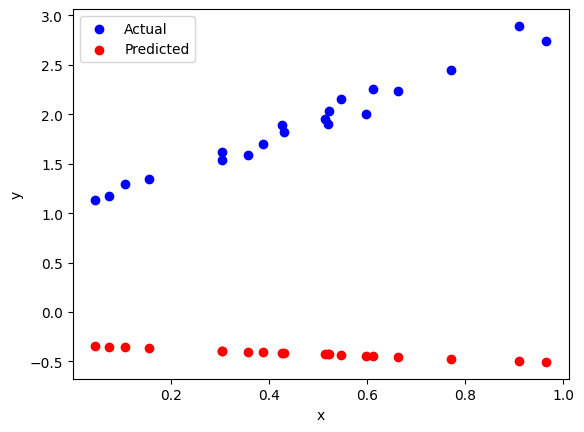

In [11]:
import matplotlib.pyplot as plt

# Convert all test data to predictions
model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device)).cpu().numpy()  # shape [N_test, 1]
# Actual Y
actuals = y_test_t.numpy()
# X values
x_vals = X_test_t.numpy()

plt.scatter(x_vals, actuals, label='Actual', color='blue')
plt.scatter(x_vals, preds, label='Predicted', color='red')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
